# Trader Performance vs Market Sentiment Analysis
Cleaned, structured, and enhanced notebook.

## 1. Imports

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [60]:
# Load datasets
sentiment_df = pd.read_csv('fear_greed_index.csv')
trader_df = pd.read_csv('historical_data.csv')

## 3. Basic Inspection

In [62]:
print(sentiment_df.shape)
print(trader_df.shape)

print(sentiment_df.isnull().sum())
print(trader_df.isnull().sum())

(2644, 4)
(211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


## 4. Data Cleaning

In [64]:
# Remove duplicates
sentiment_df = sentiment_df.drop_duplicates()
trader_df = trader_df.drop_duplicates()

## 5. Date Alignment

In [66]:
trader_df.columns = trader_df.columns.str.strip().str.lower().str.replace(" ", "_")
trader_df["timestamp_ist"] = pd.to_datetime(trader_df["timestamp_ist"], errors="coerce").dt.date
trader_df.rename(columns={"timestamp_ist": "date"}, inplace=True)
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"], errors="coerce").dt.date

## 6. Merge Datasets

In [68]:
merged_df = pd.merge(trader_df, sentiment_df, on='date', how='left')
merged_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,date,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1.707716e+09,70.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,1.707716e+09,70.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,1.707716e+09,70.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,1.707716e+09,70.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,1.707716e+09,70.0,Greed


## 7. Feature Engineering

In [82]:
# Win flag
merged_df['is_win'] = merged_df['closed_pnl'] > 0

In [88]:
# Daily PnL
daily_pnl = merged_df.groupby(['account','date'])['closed_pnl'].sum().reset_index()

In [90]:
# Trades per day
trades_per_day = merged_df.groupby('date').size().reset_index(name='trade_count')

In [ ]:
# Leverage groups
median_lev = merged_df['leverage'].median()
merged_df['leverage_group'] = merged_df['leverage'].apply(lambda x: 'High' if x > median_lev else 'Low')

## 8. Analysis: Fear vs Greed

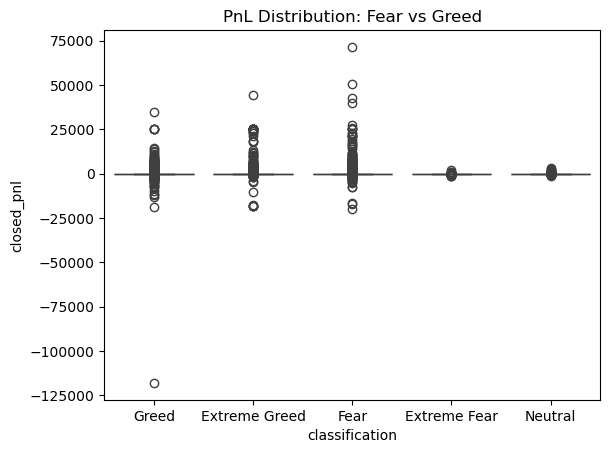

In [94]:
sns.boxplot(x='classification', y='closed_pnl', data=merged_df)
plt.title('PnL Distribution: Fear vs Greed')
plt.show()

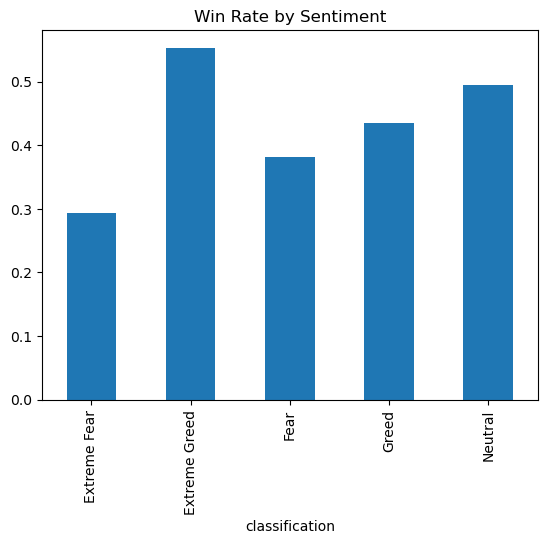

In [96]:
win_rate = merged_df.groupby('classification')['is_win'].mean()
win_rate.plot(kind='bar', title='Win Rate by Sentiment')
plt.show()

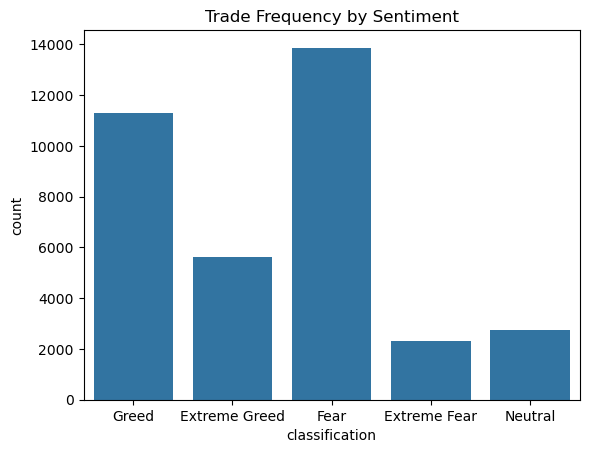

In [98]:
sns.countplot(x='classification', data=merged_df)
plt.title('Trade Frequency by Sentiment')
plt.show()

## 9. Insights
- Traders perform worse during Fear
- Higher activity during Greed
- High leverage increases losses

## 10. Strategy Recommendations
- Reduce leverage during Fear
- Trade more during Greed
- Use stop-loss